<a href="https://colab.research.google.com/github/jyotiNatlekar/CSL701-CS38_Machine-Learning-Lab/blob/main/CS38exp5ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name : Jyoti Vijay Natlekar.
Roll No : CS38

### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.


## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

Use dataset using the link  
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [ ]:
from google.colab import files
import pandas as pd
import io

# Upload dataset from your computer
uploaded = files.upload()

# Get uploaded file name
filename = list(uploaded.keys())[0]

# Column names
columns = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age',
    'Outcome'
]

# Load dataset
df = pd.read_csv(
    io.BytesIO(uploaded[filename]),
    header=None,
    names=columns
)

print("Dataset loaded successfully!\n")

print(df.head())
print("\nDataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

Saving diabetes.csv to diabetes (1).csv
Dataset loaded successfully!

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0  Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI   
1            6      148             72             35    169.5  33.6   
2            1       85             66             29    102.5  26.6   
3            8      183             64             32    169.5  23.3   
4            1       89             66             23       94  28.1   

   DiabetesPedigreeFunction  Age  Outcome  
0  DiabetesPedigreeFunction  Age  Outcome  
1                     0.627   50        1  
2                     0.351   31        0  
3                     0.672   32        1  
4                     0.167   21        0  

Dataset Shape: (769, 9)

Data Types:
Pregnancies                 object
Glucose                     object
BloodPressure               object
SkinThickness               object
Insulin                     object
BMI                 

## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

Class Distribution:
Outcome
0          500
1          268
Outcome      1
Name: count, dtype: int64


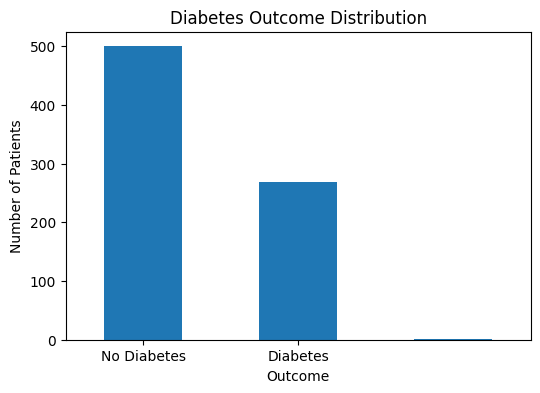

In [ ]:
import matplotlib.pyplot as plt

# Count of each class
print("Class Distribution:")
print(df['Outcome'].value_counts())

# Bar Chart of Diabetes Outcome
plt.figure(figsize=(6, 4))
df['Outcome'].value_counts().plot(kind='bar')

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["No Diabetes", "Diabetes"], rotation=0)

plt.show()

#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [ ]:
import numpy as np

# Drop the first row which contains the original header values
df = df.iloc[1:].copy()

# Convert relevant columns to numeric type
for col in df.columns:
    if col not in ['Outcome']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    else:
        df[col] = df[col].astype(int)

# Features where 0 is physically impossible
invalid_zero_columns = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

# Replace 0 values with NaN
df[invalid_zero_columns] = df[invalid_zero_columns].replace(0, np.nan)

# Check missing values before handling them
print("Missing values before imputation:")
print(df.isnull().sum())

# Replace missing values with median
for column in invalid_zero_columns:
    df[column] = df[column].fillna(df[column].median())

# Check missing values after handling them
print("\nMissing values after imputation:")
print(df.isnull().sum())

# Display dataset
print("\nDataset after preprocessing:")
print(df.head())

Missing values before imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Dataset after preprocessing:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
1            6      148           72.0             35    169.5  33.6   
2            1       85           66.0             29    102.5  26.6   
3            8      183           64.0             32    169.5  23.3   
4            1       89           66.0          

#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [ ]:
# Separate features and target

X = df.iloc[:, :8]
y = df.iloc[:, 8]

# Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display shapes
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

print("\nTraining Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

# Check class proportions
print("\nOriginal Class Proportions:")
print(y.value_counts(normalize=True))

print("\nTraining Class Proportions:")
print(y_train.value_counts(normalize=True))

print("\nTesting Class Proportions:")
print(y_test.value_counts(normalize=True))

Training Features Shape: (614, 8)
Testing Features Shape: (154, 8)

Training Target Shape: (614,)
Testing Target Shape: (154,)

Original Class Proportions:
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

Training Class Proportions:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Testing Class Proportions:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [ ]:
import numpy as np

def get_bootstrap_sample(X, y):

    # Number of training samples
    N = len(X)

    # Generate N random indices with replacement
    indices = np.random.choice(N, size=N, replace=True)

    # Create bootstrap samples
    X_bootstrap = X.iloc[indices]
    y_bootstrap = y.iloc[indices]

    return X_bootstrap, y_bootstrap, indices


# Generate bootstrap sample
X_bootstrap, y_bootstrap, bootstrap_indices = get_bootstrap_sample(
    X_train,
    y_train
)

# Display size
print("Original Training Size:", len(X_train))
print("Bootstrap Sample Size:", len(X_bootstrap))


# Find duplicated indices
unique_indices = np.unique(bootstrap_indices)
duplicate_count = len(bootstrap_indices) - len(unique_indices)

print("\nNumber of Duplicated Rows:", duplicate_count)


# Find OOB (omitted) indices
all_indices = np.arange(len(X_train))

oob_indices = np.setdiff1d(
    all_indices,
    unique_indices
)

print("Number of OOB Rows:", len(oob_indices))

print("\nFirst 10 Bootstrap Indices:")
print(bootstrap_indices[:10])

print("\nFirst 10 OOB Indices:")
print(oob_indices[:10])

Original Training Size: 614
Bootstrap Sample Size: 614

Number of Duplicated Rows: 232
Number of OOB Rows: 232

First 10 Bootstrap Indices:
[153 210 525 505 125  51 109 456 522 229]

First 10 OOB Indices:
[ 1  5  6  7 12 14 15 18 19 20]


#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [ ]:
# Number of bootstrap iterations
B = 50

# Empty list to store trained models
ensemble_models = []

# Train B decision trees
for i in range(B):

    # Generate bootstrap sample using Task 5 function
    X_bootstrap, y_bootstrap, bootstrap_indices = get_bootstrap_sample(
        X_train,
        y_train
    )

    # Create fully grown Decision Tree
    model = DecisionTreeClassifier(
        max_depth=None,
        random_state=i
    )

    # Train the model
    model.fit(X_bootstrap, y_bootstrap)

    # Add trained model to ensemble
    ensemble_models.append(model)


# Verify number of trained models
print("Number of Decision Trees in Ensemble:", len(ensemble_models))

Number of Decision Trees in Ensemble: 50


#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [ ]:
def custom_bagging_predict(ensemble, X_test):

    # Store predictions from all models
    all_predictions = []

    # Get predictions from every decision tree
    for model in ensemble:
        predictions = model.predict(X_test)
        all_predictions.append(predictions)

    # Convert predictions into NumPy array
    all_predictions = np.array(all_predictions)

    # Store final majority voting predictions
    final_predictions = []

    # Perform majority voting for each test sample
    for i in range(len(X_test)):

        # Get votes for current sample
        votes = all_predictions[:, i]

        # Count votes for class 0 and class 1
        count_0 = np.sum(votes == 0)
        count_1 = np.sum(votes == 1)

        # Select class with maximum votes
        if count_1 > count_0:
            final_predictions.append(1)
        else:
            final_predictions.append(0)

    return np.array(final_predictions)


# Generate final Bagging predictions
bagging_predictions = custom_bagging_predict(
    ensemble_models,
    X_test
)

# Display predictions
print("First 20 Bagging Predictions:")
print(bagging_predictions[:20])

# Verify possible output classes
print("\nUnique Predicted Classes:")
print(np.unique(bagging_predictions))

First 20 Bagging Predictions:
[0 0 0 1 0 0 1 1 0 1 0 1 0 0 1 1 0 0 1 0]

Unique Predicted Classes:
[0 1]


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.

In [ ]:
# Train a single Decision Tree Classifier
single_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

# Train on original training data
single_tree.fit(X_train, y_train)

# Prediction using single Decision Tree
single_tree_predictions = single_tree.predict(X_test)

# Bagging predictions were already generated in Task 7
# bagging_predictions


# -------------------------------
# Confusion Matrix
# -------------------------------

print("Single Decision Tree Confusion Matrix:")
print(confusion_matrix(y_test, single_tree_predictions))

print("\nCustom Bagging Confusion Matrix:")
print(confusion_matrix(y_test, bagging_predictions))


# -------------------------------
# Single Decision Tree Metrics
# -------------------------------

print("\n----- Single Decision Tree Performance -----")

print("Accuracy:",
      accuracy_score(y_test, single_tree_predictions))

print("Precision:",
      precision_score(y_test, single_tree_predictions))

print("Recall:",
      recall_score(y_test, single_tree_predictions))

print("F1-Score:",
      f1_score(y_test, single_tree_predictions))


# -------------------------------
# Custom Bagging Metrics
# -------------------------------

print("\n----- Custom Bagging Performance -----")

print("Accuracy:",
      accuracy_score(y_test, bagging_predictions))

print("Precision:",
      precision_score(y_test, bagging_predictions))

print("Recall:",
      recall_score(y_test, bagging_predictions))

print("F1-Score:",
      f1_score(y_test, bagging_predictions))

Single Decision Tree Confusion Matrix:
[[87 13]
 [16 38]]

Custom Bagging Confusion Matrix:
[[92  8]
 [ 8 46]]

----- Single Decision Tree Performance -----
Accuracy: 0.8116883116883117
Precision: 0.7450980392156863
Recall: 0.7037037037037037
F1-Score: 0.7238095238095238

----- Custom Bagging Performance -----
Accuracy: 0.8961038961038961
Precision: 0.8518518518518519
Recall: 0.8518518518518519
F1-Score: 0.8518518518518519


#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.

Single Decision Tree AUC: 0.7868518518518519
Custom Bagging AUC: 0.9526851851851852


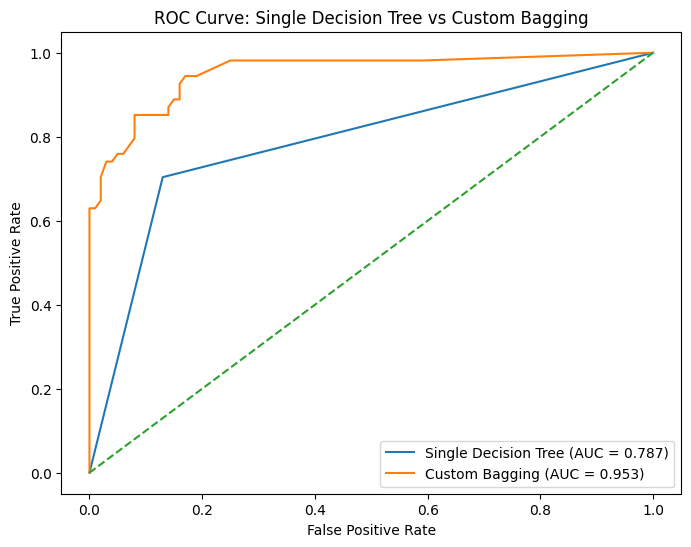

In [ ]:
# ---------------------------------
# Bagging Probability Prediction
# ---------------------------------

def custom_bagging_predict_proba(ensemble, X_test):

    # Store probability predictions from all trees
    all_probabilities = []

    for model in ensemble:
        probabilities = model.predict_proba(X_test)
        all_probabilities.append(probabilities)

    # Convert to NumPy array
    all_probabilities = np.array(all_probabilities)

    # Average probabilities across all decision trees
    average_probabilities = np.mean(all_probabilities, axis=0)

    return average_probabilities


# Get Bagging probabilities
bagging_probabilities = custom_bagging_predict_proba(
    ensemble_models,
    X_test
)

# Probability of class 1 (Diabetes)
bagging_prob_class1 = bagging_probabilities[:, 1]


# ---------------------------------
# Single Decision Tree Probabilities
# ---------------------------------

single_tree_probabilities = single_tree.predict_proba(X_test)

# Probability of class 1
single_tree_prob_class1 = single_tree_probabilities[:, 1]


# ---------------------------------
# Calculate ROC Curve
# ---------------------------------

fpr_single, tpr_single, thresholds_single = roc_curve(
    y_test,
    single_tree_prob_class1
)

fpr_bagging, tpr_bagging, thresholds_bagging = roc_curve(
    y_test,
    bagging_prob_class1
)


# ---------------------------------
# Calculate AUC
# ---------------------------------

auc_single = roc_auc_score(
    y_test,
    single_tree_prob_class1
)

auc_bagging = roc_auc_score(
    y_test,
    bagging_prob_class1
)

print("Single Decision Tree AUC:", auc_single)
print("Custom Bagging AUC:", auc_bagging)


# ---------------------------------
# Plot ROC Curves
# ---------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_single,
    tpr_single,
    label=f"Single Decision Tree (AUC = {auc_single:.3f})"
)

plt.plot(
    fpr_bagging,
    tpr_bagging,
    label=f"Custom Bagging (AUC = {auc_bagging:.3f})"
)

# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve: Single Decision Tree vs Custom Bagging")

plt.legend()

plt.show()

#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.

In [ ]:
from sklearn.ensemble import BaggingClassifier

# Create base Decision Tree
base_tree = DecisionTreeClassifier(
    max_depth=None
)

# Create Scikit-Learn Bagging Classifier
sklearn_bagging = BaggingClassifier(
    estimator=base_tree,
    n_estimators=50,
    random_state=42
)

# Train the model
sklearn_bagging.fit(X_train, y_train)

# Make predictions
sklearn_bagging_predictions = sklearn_bagging.predict(X_test)


# --------------------------------
# Scikit-Learn Bagging Accuracy
# --------------------------------

sklearn_accuracy = accuracy_score(
    y_test,
    sklearn_bagging_predictions
)

print("Scikit-Learn Bagging Accuracy:", sklearn_accuracy)


# --------------------------------
# Scikit-Learn Confusion Matrix
# --------------------------------

print("\nScikit-Learn Bagging Confusion Matrix:")

print(
    confusion_matrix(
        y_test,
        sklearn_bagging_predictions
    )
)


# --------------------------------
# Custom Bagging Accuracy
# --------------------------------

custom_accuracy = accuracy_score(
    y_test,
    bagging_predictions
)

print("\nCustom Bagging Accuracy:", custom_accuracy)


# --------------------------------
# Custom Bagging Confusion Matrix
# --------------------------------

print("\nCustom Bagging Confusion Matrix:")

print(
    confusion_matrix(
        y_test,
        bagging_predictions
    )
)


# --------------------------------
# Final Comparison
# --------------------------------

comparison = pd.DataFrame({
    "Model": [
        "Custom Bagging",
        "Scikit-Learn Bagging"
    ],

    "Accuracy": [
        custom_accuracy,
        sklearn_accuracy
    ]
})

print("\nFinal Comparison:")
print(comparison)

Scikit-Learn Bagging Accuracy: 0.8831168831168831

Scikit-Learn Bagging Confusion Matrix:
[[91  9]
 [ 9 45]]

Custom Bagging Accuracy: 0.8961038961038961

Custom Bagging Confusion Matrix:
[[92  8]
 [ 8 46]]

Final Comparison:
                  Model  Accuracy
0        Custom Bagging  0.896104
1  Scikit-Learn Bagging  0.883117


### **Conclusion and Interpretation**

Students should summarize their findings by answering the following key questions:

1. **Variance and Stability:** How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?

2. **Wisdom of Crowds:** How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?

3. **Clinical Interpretation:** In predicting diabetes, why are False Negatives (predicting non-diabetic for a diabetic patient) especially costly, and how does Bagging's Recall metric help minimize this risk compared to a single decision tree?